# Kilonova dataloader

**Parte 1 — Curva de luz sin extinción ni ruido.** Dada una kilonova del grid LANL (simulación + ángulo de visión) y un redshift, redshiftea + atenúa por distancia el espectro de cada época e integra a través de los bandpasses de `galsim.roman` para obtener la magnitud AB verdadera por banda. Sin extinción de host ni de la Vía Láctea, sin ruido observacional.

**Parte 2 — Error de observación Roman.** Toma esa magnitud verdadera por banda/época y le agrega el error fotométrico con la receta de `galsim.roman` (sky + thermal + dark + read sobre la NEA del PSF + Poisson de la fuente), idéntica a `openuniverse_hdf5_lightcurve_error.ipynb`. De ahí salen SNR, barra de error y el flag de detección S/N ≥ 5.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path

from astropy import units as u
from astropy.cosmology import Planck18

from specutils import Spectrum

import galsim
import galsim.roman as roman

FLUX_UNIT = u.Unit('erg / (s cm2 AA)')

# Override con la variable de entorno LANL_SPECTRA_PATH; por defecto, ruta relativa al notebook
# (data/openuniverse -> ../dust_generation/lanl_spectra.parquet), para correr en cualquier maquina.
LANL_SPECTRA_PATH = Path(os.environ.get(
    'LANL_SPECTRA_PATH', Path.cwd() / '..' / 'dust_generation' / 'lanl_spectra.parquet',
)).resolve()
N_ANGLE_BINS = 54
INTRINSIC_DISTANCE_PARSEC = 10.0  # the LANL flux_rest is the absolute flux of the source at 10 pc


In [2]:
# Roman bandpasses / AB zeropoints from galsim.roman. La fotometria sintetica de la Parte 1 y la
# receta de error de la Parte 2 comparten estos mismos bandpasses, asi que la magnitud verdadera
# entra directo a la receta de error sin remapear nombres de banda.
ROMAN_BANDPASSES = roman.getBandpasses()
ALL_ROMAN_BANDS = ['R062', 'Z087', 'Y106', 'J129', 'H158', 'F184']
ROMAN_ZEROPOINT = {band: ROMAN_BANDPASSES[band].zeropoint for band in ALL_ROMAN_BANDS}
COLLECTING_AREA_CM2 = roman.collecting_area

BAND_WAVELENGTH_MICRON = {'R062': 0.62, 'Z087': 0.87, 'Y106': 1.06, 'J129': 1.29, 'H158': 1.58, 'F184': 1.84}
BAND_COLOR = {band: plt.cm.turbo((wavelength - 0.55) / 1.7)
              for band, wavelength in BAND_WAVELENGTH_MICRON.items()}


In [ ]:
import os
from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq

# Override con la variable de entorno LANL_SPECTRA_PATH; por defecto, ruta relativa al notebook
# (data/openuniverse -> ../dust_generation/lanl_spectra.parquet), para correr en cualquier maquina.
LANL_SPECTRA_PATH = Path(os.environ.get(
    'LANL_SPECTRA_PATH', Path.cwd() / '..' / 'dust_generation' / 'lanl_spectra.parquet',
)).resolve()
CM_TO_ANG = (1 * u.cm).to(u.AA).value
Z_AT2017 = 0.009783
N_ANGLE_BINS = 54

LANL_METADATA_COLUMNS = [
    'simulation_id', 'run_type', 'wind',
    'mass_dynamical', 'velocity_dynamical', 'mass_wind', 'velocity_wind',
    'time_index', 'time_days', 'angle_index',
]


def plot_lanl_catalog(catalog):
    file_catalog = catalog.drop_duplicates(subset='simulation_id')
    colors = {'wind1': 'C0', 'wind2': 'C3'}
    markers = {'TP': 'o', 'TS': 's'}

    figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for run_type in sorted(file_catalog['run_type'].unique()):
        for wind in sorted(file_catalog['wind'].unique()):
            subset = file_catalog[
                (file_catalog['run_type'] == run_type) & (file_catalog['wind'] == wind)
            ]
            axes[0].scatter(
                subset['mass_dynamical'], subset['velocity_dynamical'],
                color=colors[wind], marker=markers[run_type], alpha=0.6, s=50,
                label=f'{run_type} {wind}',
            )
            axes[1].scatter(
                subset['mass_wind'], subset['velocity_wind'],
                color=colors[wind], marker=markers[run_type], alpha=0.6, s=50,
            )
    for axis, xlabel, ylabel, title in zip(
        axes,
        [r'$M_{\rm dyn}\ [M_\odot]$', r'$M_{\rm wind}\ [M_\odot]$'],
        [r'$v_{\rm dyn}\ [c]$', r'$v_{\rm wind}\ [c]$'],
        ['Dynamical ejecta', 'Wind ejecta'],
    ):
        axis.set_xlabel(xlabel, fontsize=12)
        axis.set_ylabel(ylabel, fontsize=12)
        axis.set_title(title, fontsize=12)
        axis.set_xscale('log')
        axis.grid(alpha=0.25)
    axes[0].legend(frameon=False, fontsize=9)
    n_sims = catalog['simulation_id'].nunique()
    n_times = catalog.groupby('simulation_id')['time_index'].nunique().mean()
    figure.suptitle(
        f'LANL grid — {n_sims} simulations  ×  ~{n_times:.0f} time steps  ×  {N_ANGLE_BINS} angles'
        f'  =  {len(catalog):,} spectra',
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


def load_lanl_catalog(spectra_path=LANL_SPECTRA_PATH, plot=True):
    """Load LANL catalog metadata only (no flux_rest). Also returns the rest-frame wavelength grid."""
    parquet_file = pq.ParquetFile(spectra_path)
    metadata = parquet_file.schema_arrow.metadata or {}
    wavelength_bytes = metadata.get(b'wavelength_rest_aa')
    if wavelength_bytes is None:
        raise RuntimeError(f'{spectra_path}: missing schema metadata key wavelength_rest_aa')
    wavelength_rest_aa = np.frombuffer(wavelength_bytes, dtype=np.float32).astype(float)

    catalog = parquet_file.read(columns=LANL_METADATA_COLUMNS).to_pandas()
    catalog.index.name = 'spectrum_id'
    print(f'Loaded metadata from {spectra_path}  ({len(catalog):,} rows, {wavelength_rest_aa.size} wavelengths)')

    if plot:
        plot_lanl_catalog(catalog)
        print(f'Total spectra:  {len(catalog):,}')
        print(f'Simulations:    {catalog["simulation_id"].nunique()}')
        print(f'Time range:     {catalog["time_days"].min():.3f} – {catalog["time_days"].max():.3f} days')
        print(f'Angles:         {N_ANGLE_BINS}')

    return catalog, wavelength_rest_aa


def load_lanl_flux(spectrum_id, catalog, spectra_path=LANL_SPECTRA_PATH):
    """Lazy-load a single rest-frame spectrum from the parquet.

    Reads only the row group that contains ``spectrum_id`` (each .dat-file produced
    one row group in cache_lanl_spectra.py), so this stays cheap even with 3.3M rows.
    """
    spectrum_id = int(spectrum_id)
    simulation_id = int(catalog.loc[spectrum_id, 'simulation_id'])
    time_index = int(catalog.loc[spectrum_id, 'time_index'])
    angle_index = int(catalog.loc[spectrum_id, 'angle_index'])

    parquet_file = pq.ParquetFile(spectra_path)
    for group_index in range(parquet_file.num_row_groups):
        statistics = parquet_file.metadata.row_group(group_index).column(
            parquet_file.schema_arrow.get_field_index('simulation_id')
        ).statistics
        if statistics is None:
            continue
        if statistics.min <= simulation_id <= statistics.max:
            row_group = parquet_file.read_row_group(
                group_index,
                columns=['simulation_id', 'time_index', 'angle_index', 'flux_rest'],
            )
            mask = (
                (row_group.column('simulation_id').to_numpy() == simulation_id)
                & (row_group.column('time_index').to_numpy() == time_index)
                & (row_group.column('angle_index').to_numpy() == angle_index)
            )
            indices = np.flatnonzero(mask)
            if indices.size:
                return np.asarray(row_group.column('flux_rest')[int(indices[0])].as_py(), dtype=float)

    raise KeyError(f'spectrum_id={spectrum_id} not found in {spectra_path}')


catalog, lanl_lambda_rest_aa = load_lanl_catalog(plot=True)

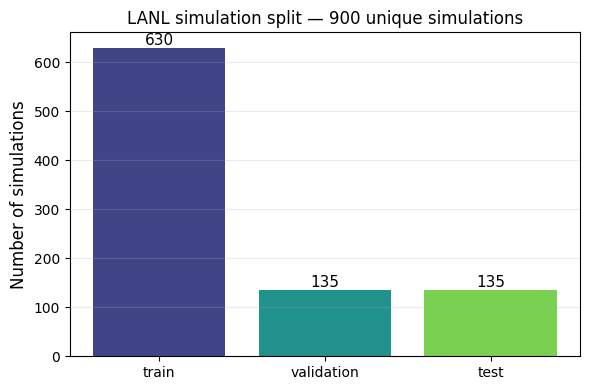

  train       n=630
  validation  n=135
  test        n=135


In [4]:
def plot_simulation_splits(simulation_splits):
    split_names = list(simulation_splits.keys())
    split_sizes = [len(simulation_splits[name]) for name in split_names]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(split_names)))

    figure, axis = plt.subplots(figsize=(6, 4))
    bars = axis.bar(split_names, split_sizes, color=colors)
    for bar, size in zip(bars, split_sizes):
        axis.text(bar.get_x() + bar.get_width() / 2, size, str(size),
                  ha='center', va='bottom', fontsize=11)
    axis.set_ylabel('Number of simulations', fontsize=12)
    axis.set_title(f'LANL simulation split — {sum(split_sizes)} unique simulations', fontsize=12)
    axis.grid(alpha=0.25, axis='y')
    plt.tight_layout()
    plt.show()


def split_lanl_simulations(catalog, fractions=(0.70, 0.15, 0.15), random_seed=42, plot=True):
    """Split the unique LANL simulations into train/validation/test by simulation_id."""
    simulation_ids = np.sort(catalog['simulation_id'].unique())
    number_of_simulations = simulation_ids.size

    random_generator = np.random.default_rng(random_seed)
    shuffled_ids = random_generator.permutation(simulation_ids)

    train_fraction, validation_fraction, _ = fractions
    train_end = int(round(train_fraction * number_of_simulations))
    validation_end = train_end + int(round(validation_fraction * number_of_simulations))

    simulation_splits = {
        'train': np.sort(shuffled_ids[:train_end]),
        'validation': np.sort(shuffled_ids[train_end:validation_end]),
        'test': np.sort(shuffled_ids[validation_end:]),
    }

    all_split_ids = np.concatenate(list(simulation_splits.values()))
    assert all_split_ids.size == number_of_simulations
    assert np.unique(all_split_ids).size == number_of_simulations

    if plot:
        plot_simulation_splits(simulation_splits)
        for split_name, split_ids in simulation_splits.items():
            print(f'  {split_name:<11} n={split_ids.size}')

    return simulation_splits


simulation_splits = split_lanl_simulations(catalog, plot=True)

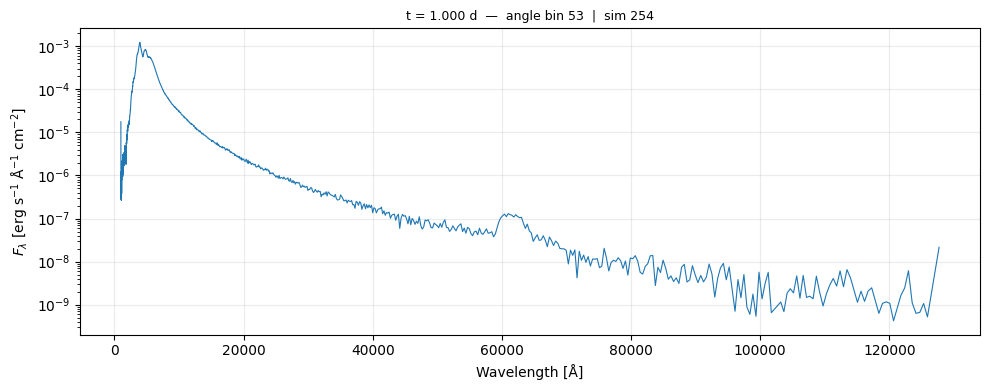

In [5]:
def plot_lanl_spectrum(time_days, lam_AA, flux_lambda, angle_index, simulation_id=None):
    figure, axis = plt.subplots(figsize=(10, 4))
    axis.plot(lam_AA, flux_lambda, lw=0.8, color='C0')
    axis.set_xlabel(r'Wavelength [Å]')
    axis.set_ylabel(r'$F_\lambda$ [erg s$^{-1}$ Å$^{-1}$ cm$^{-2}$]')
    title = f't = {time_days:.3f} d  —  angle bin {angle_index}'
    if simulation_id is not None:
        title += f'  |  sim {simulation_id}'
    axis.set_title(title, fontsize=9)
    axis.set_yscale('log')
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def load_lanl_spectrum(spectrum_id, catalog=catalog, wavelength_rest_aa=lanl_lambda_rest_aa, plot=True):
    """Lazy-load one rest-frame spectrum from lanl_spectra.parquet."""
    row = catalog.loc[spectrum_id]
    simulation_id = int(row['simulation_id'])
    angle_index = int(row['angle_index'])
    time_days = float(row['time_days'])

    flux = load_lanl_flux(spectrum_id, catalog)
    valid_mask = flux > 0
    lam_valid = wavelength_rest_aa[valid_mask]
    flux_valid = flux[valid_mask]
    if plot:
        plot_lanl_spectrum(time_days, lam_valid, flux_valid, angle_index, simulation_id=simulation_id)
    return lam_valid, flux_valid


# sim 253 (TP wind2, angle 53) at t = 1.0 d after merger
lam_valid, spectrum = load_lanl_spectrum(spectrum_id=937925, plot=True)

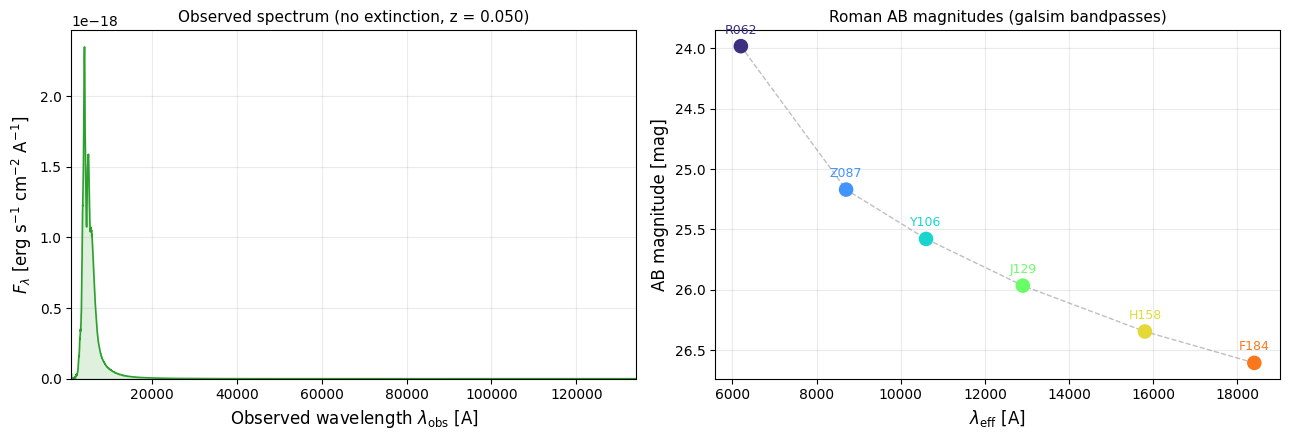

z = 0.050   d_L = 2.299e+08 pc
  R062: 23.982 mag
  Z087: 25.169 mag
  Y106: 25.578 mag
  J129: 25.965 mag
  H158: 26.345 mag
  F184: 26.605 mag


In [6]:
# Receta de fotometría sintética de KN (SED LANL -> mag AB Roman) en kilonova_spectra.py: misma
# que usa generate_early_windows.py. Aquí solo se le agrega el plot del espectro observado + magnitudes.
from kilonova_spectra import redshift_and_dim_spectrum, spectrum_to_roman_magnitudes


def plot_observed_spectrum_and_magnitudes(wavelength_observed_aa, flux_observed_lambda, magnitudes,
                                          redshift, save_path=None):
    figure, (axis_spectrum, axis_magnitudes) = plt.subplots(1, 2, figsize=(13, 4.5))

    axis_spectrum.plot(wavelength_observed_aa, flux_observed_lambda, color='C2', lw=1.2)
    axis_spectrum.fill_between(wavelength_observed_aa, 0, flux_observed_lambda, color='C2', alpha=0.15)
    axis_spectrum.set_xlabel(r'Observed wavelength $\lambda_{\rm obs}$ [A]', fontsize=12)
    axis_spectrum.set_ylabel(r'$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ A$^{-1}$]', fontsize=12)
    axis_spectrum.set_title(f'Observed spectrum (no extinction, z = {redshift:.3f})', fontsize=11)
    axis_spectrum.set_xlim(wavelength_observed_aa.min(), wavelength_observed_aa.max())
    axis_spectrum.set_ylim(bottom=0)
    axis_spectrum.grid(alpha=0.25)

    bands = [band for band in magnitudes if np.isfinite(magnitudes[band])]
    effective_wavelengths = [BAND_WAVELENGTH_MICRON[band] * 1e4 for band in bands]
    band_magnitudes = [magnitudes[band] for band in bands]
    axis_magnitudes.scatter(effective_wavelengths, band_magnitudes,
                            c=[BAND_COLOR[band] for band in bands], s=90, zorder=3)
    axis_magnitudes.plot(effective_wavelengths, band_magnitudes, color='gray', lw=1.0, ls='--', alpha=0.5)
    for band, wavelength_eff, magnitude in zip(bands, effective_wavelengths, band_magnitudes):
        axis_magnitudes.annotate(band, (wavelength_eff, magnitude), textcoords='offset points',
                                 xytext=(0, 9), ha='center', fontsize=9, color=BAND_COLOR[band])
    axis_magnitudes.set_xlabel(r'$\lambda_{\rm eff}$ [A]', fontsize=12)
    axis_magnitudes.set_ylabel('AB magnitude [mag]', fontsize=12)
    axis_magnitudes.set_title('Roman AB magnitudes (galsim bandpasses)', fontsize=11)
    axis_magnitudes.invert_yaxis()
    axis_magnitudes.grid(alpha=0.25)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def observe_spectrum(wavelength_rest_aa, flux_rest_lambda, redshift, bands=ALL_ROMAN_BANDS, plot=True):
    wavelength_observed_aa, flux_observed_lambda, luminosity_distance_parsec = redshift_and_dim_spectrum(
        wavelength_rest_aa, flux_rest_lambda, redshift,
    )
    magnitudes = spectrum_to_roman_magnitudes(wavelength_observed_aa, flux_observed_lambda, bands=bands)
    if plot:
        plot_observed_spectrum_and_magnitudes(wavelength_observed_aa, flux_observed_lambda, magnitudes, redshift)
        print(f'z = {redshift:.3f}   d_L = {luminosity_distance_parsec:.3e} pc')
        for band in bands:
            print(f'  {band}: {magnitudes[band]:.3f} mag')
    return magnitudes


# demo: un espectro LANL redshifteado a z = 0.05 con sus magnitudes AB Roman
demo_wavelength_rest, demo_flux_rest = load_lanl_spectrum(spectrum_id=937925, plot=False)
_ = observe_spectrum(demo_wavelength_rest, demo_flux_rest, redshift=0.05, plot=True)


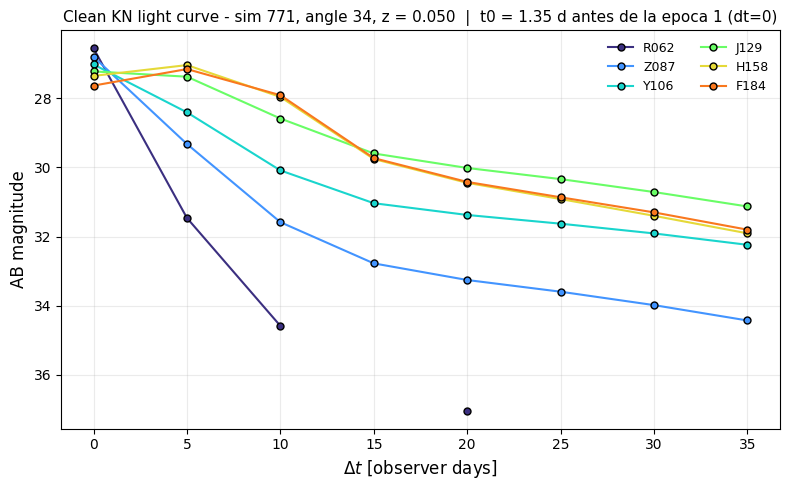

In [7]:
# Cadencia del survey (gap de BASE_CADENCE_DAYS d). Se generan N_VISITS visitas y de ahi se eligen las
# N_EPOCHS_FROM_DETECTION epocas desde la PRIMERA deteccion S/N>=5 (no desde la visita dt=0): el merger
# puede caer en cualquier visita porque el offset de explosion t0 ~ U[0,5] de sample_kilonova_realization
# lo desplaza dentro del primer gap, asi que la primera deteccion no tiene por que ocurrir en dt=0.
BASE_CADENCE_DAYS = 5.0
N_VISITS = 8
N_EPOCHS_FROM_DETECTION = 3
EPOCH_DELTA_TIMES = tuple(BASE_CADENCE_DAYS * np.arange(N_VISITS))  # 0,5,...,(N_VISITS-1)*5 d observador


def build_simulation_time_grids(catalog):
    """Per-simulation (time_index, time_days) ordenados por fase, para el nearest-rest-phase lookup."""
    unique_times = catalog.drop_duplicates(['simulation_id', 'time_index'])[
        ['simulation_id', 'time_index', 'time_days']
    ]
    simulation_time_grids = {}
    for simulation_id, group in unique_times.groupby('simulation_id'):
        ordered = group.sort_values('time_days')
        simulation_time_grids[int(simulation_id)] = (
            ordered['time_index'].to_numpy(), ordered['time_days'].to_numpy(),
        )
    return simulation_time_grids


def nearest_time_index(simulation_time_grids, simulation_id, rest_phase_days):
    time_index_array, time_days_array = simulation_time_grids[int(simulation_id)]
    nearest_position = int(np.argmin(np.abs(time_days_array - rest_phase_days)))
    return int(time_index_array[nearest_position])


def sample_kilonova_realization(random_generator, simulation_pool, n_angle_bins=N_ANGLE_BINS,
                                explosion_offset_max_days=5.0):
    """Una KN aleatoria, fija a lo largo de sus epocas: simulacion (masa/progenitor/tipo) + angulo de
    vision + offset de explosion t0 ~ U[0, max] (dias observador entre el merger y la epoca 1)."""
    return {
        'simulation_id': int(random_generator.choice(simulation_pool)),
        'angle_index': int(random_generator.integers(n_angle_bins)),
        'explosion_offset_days': float(random_generator.uniform(0.0, explosion_offset_max_days)),
    }


def generate_kilonova_lightcurve(realization, redshift, simulation_time_grids, spectrum_id_lookup,
                                 object_index=0, epoch_dts=EPOCH_DELTA_TIMES, bands=ALL_ROMAN_BANDS):
    """Curva de luz verdadera (magnitud AB por banda) de una KN en cada epoca.
    rest_phase = (t0 + dt) / (1 + z): la KN tiene t0 dias observador en la epoca 1 (dt = 0)."""
    rows = []
    for delta_time in epoch_dts:
        rest_phase_days = (realization['explosion_offset_days'] + delta_time) / (1.0 + redshift)
        time_index = nearest_time_index(simulation_time_grids, realization['simulation_id'], rest_phase_days)
        spectrum_id = int(spectrum_id_lookup.loc[
            (realization['simulation_id'], time_index, realization['angle_index'])
        ])
        flux_rest = load_lanl_flux(spectrum_id, catalog)
        valid_mask = flux_rest > 0
        magnitudes = observe_spectrum(
            lanl_lambda_rest_aa[valid_mask], flux_rest[valid_mask], redshift, bands=bands, plot=False,
        )
        for band in bands:
            rows.append({'object': object_index, 'redshift': redshift, 'dt': float(delta_time),
                         'band': band, 'mag_true': magnitudes[band]})
    return pd.DataFrame(rows)


def plot_kilonova_lightcurve(lightcurve, title='', ax=None):
    own_axis = ax is None
    if own_axis:
        figure, ax = plt.subplots(figsize=(8, 5))
    for band in ALL_ROMAN_BANDS:
        band_rows = lightcurve[lightcurve['band'] == band].sort_values('dt')
        if band_rows['mag_true'].notna().any():
            ax.plot(band_rows['dt'], band_rows['mag_true'], 'o-', color=BAND_COLOR[band],
                    markersize=5, markeredgecolor='black', label=band)
    ax.invert_yaxis()
    ax.set_xlabel(r'$\Delta t$ [observer days]', fontsize=12)
    ax.set_ylabel('AB magnitude', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    ax.grid(alpha=0.25)
    if own_axis:
        plt.tight_layout()
        plt.show()


simulation_time_grids = build_simulation_time_grids(catalog)
spectrum_id_lookup = catalog.reset_index().set_index(
    ['simulation_id', 'time_index', 'angle_index']
)['spectrum_id']


def build_clean_lightcurve(redshift, split='train', random_seed=0, epoch_dts=EPOCH_DELTA_TIMES, plot=True):
    random_generator = np.random.default_rng(random_seed)
    realization = sample_kilonova_realization(random_generator, simulation_splits[split])
    lightcurve = generate_kilonova_lightcurve(
        realization, redshift, simulation_time_grids, spectrum_id_lookup, epoch_dts=epoch_dts,
    )
    if plot:
        plot_kilonova_lightcurve(
            lightcurve,
            title=(f'Clean KN light curve - sim {realization["simulation_id"]}, '
                   f'angle {realization["angle_index"]}, z = {redshift:.3f}  |  '
                   f't0 = {realization["explosion_offset_days"]:.2f} d antes de la epoca 1 (dt=0)'),
        )
    return lightcurve, realization


clean_lightcurve, realization = build_clean_lightcurve(redshift=0.05, plot=True)


## Parte 2 — Error de observación Roman (`galsim.roman`)

Toma la magnitud verdadera por banda/época de la Parte 1 y le agrega el error fotométrico con la receta de `galsim.roman`: la ecuación CCD estándar en electrones,

$$\sigma^2(F) = \underbrace{F_{\rm fuente}}_{\text{Poisson de la fuente}} + \underbrace{n_{\rm pix}\,(B_{\rm sky} + B_{\rm thermal} + B_{\rm dark} + \sigma_{\rm read}^2)}_{\text{fondo + lectura}}\,,\qquad n_{\rm pix} = {\rm NEA}$$

El `TIER` (`wide`/`deep`) fija filtros, tiempo de exposición por época y campo del HLTDS. El read noise depende de la exposición (Rose et al. 2025, eq. 9, muestreo *up-the-ramp*). Es la misma receta de `openuniverse_hdf5_lightcurve_error.ipynb`, aplicada acá a la curva verdadera de la Parte 1.

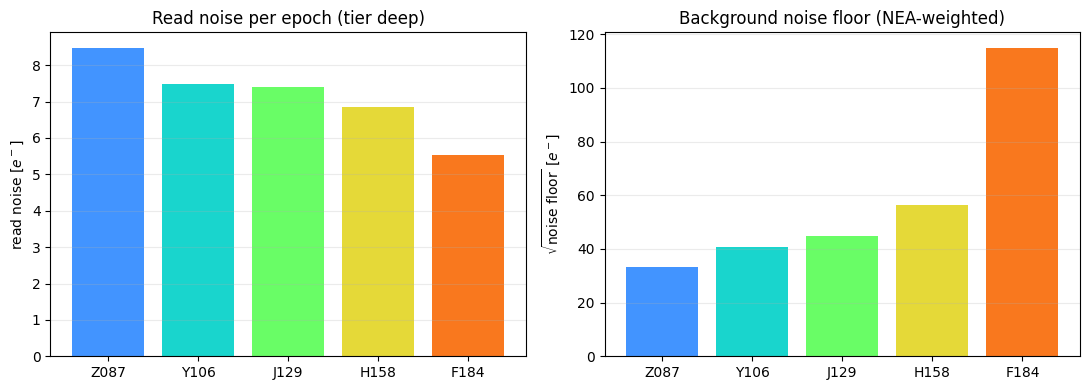

tier deep   field EDFS_a   bands ['Z087', 'Y106', 'J129', 'H158', 'F184']   anchor Z087
  visita 0 (dt=0 d): ['Z087', 'Y106', 'H158']
  visita 1 (dt=5 d): ['Z087', 'J129', 'F184']
  visita 2 (dt=10 d): ['Z087', 'Y106', 'H158']
  visita 3 (dt=15 d): ['Z087', 'J129', 'F184']
  visita 4 (dt=20 d): ['Z087', 'Y106', 'H158']
  visita 5 (dt=25 d): ['Z087', 'J129', 'F184']
  visita 6 (dt=30 d): ['Z087', 'Y106', 'H158']
  visita 7 (dt=35 d): ['Z087', 'J129', 'F184']


In [8]:
# Receta de error fotométrico Roman (fuente única de verdad): constantes y funciones se importan de
# roman_photometry.py, idénticas a openuniverse_hdf5_lightcurve_error.ipynb y generate_early_windows.py.
from roman_photometry import (
    SNR_DETECTION, ZP_JITTER_SIGMA,
    EXPOSURE_TIME_BY_TIER, TIER_ANCHOR_BAND,
    HLTDS_FIELD_CENTER, HLTDS_FIELDS_BY_TIER, PSF_NEA_PIX,
    ROMAN_ZEROPOINT, COLLECTING_AREA_CM2,
    read_noise_electrons, build_tier_constants, bands_observed_at_visit,
    source_flux_electrons, flux_error_electrons, limiting_magnitude_5sigma,
)

TIER = 'deep'  # 'wide' | 'deep' -> define filtros, exposicion y campo
EXPOSURE_TIME = EXPOSURE_TIME_BY_TIER[TIER]
TIER_BANDS = [band for band in ALL_ROMAN_BANDS if band in EXPOSURE_TIME]
ANCHOR_BAND = TIER_ANCHOR_BAND[TIER]

FIELD_SEED = 0
FIELD_NAME = str(np.random.default_rng(FIELD_SEED).choice(HLTDS_FIELDS_BY_TIER[TIER]))
FIELD_CENTER_RA, FIELD_CENTER_DEC = HLTDS_FIELD_CENTER[FIELD_NAME]

# La cadencia (qué filtros observa cada visita: anchor + 2, por paridad del índice de visita) sale de
# roman_photometry.bands_observed_at_visit — misma regla que el notebook OpenUniverse y el pipeline.

# Constantes del tier (piso de ruido NEA-pesado por banda) derivadas en roman_photometry a la exposicion
# del TIER y el campo de FIELD_SEED. read_noise_electrons / PSF_NEA_PIX / ZP_JITTER_SIGMA se importan.
def plot_noise_floor(noise_floor_variance, read_noise_by_band):
    bands = list(noise_floor_variance.keys())
    colors = [BAND_COLOR[band] for band in bands]
    figure, (axis_read, axis_floor) = plt.subplots(1, 2, figsize=(11, 4))
    axis_read.bar(bands, [read_noise_by_band[band] for band in bands], color=colors)
    axis_read.set_ylabel(r'read noise [$e^-$]')
    axis_read.set_title(f'Read noise per epoch (tier {TIER})')
    axis_read.grid(alpha=0.25, axis='y')
    axis_floor.bar(bands, [np.sqrt(noise_floor_variance[band]) for band in bands], color=colors)
    axis_floor.set_ylabel(r'$\sqrt{\rm noise\ floor}$ [$e^-$]')
    axis_floor.set_title('Background noise floor (NEA-weighted)')
    axis_floor.grid(alpha=0.25, axis='y')
    plt.tight_layout()
    plt.show()


_tier_constants = build_tier_constants(TIER, field_seed=FIELD_SEED)
NOISE_FLOOR_VARIANCE = _tier_constants['noise_floor_variance']
READ_NOISE_BY_BAND = {band: read_noise_electrons(EXPOSURE_TIME[band]) for band in TIER_BANDS}
plot_noise_floor(NOISE_FLOOR_VARIANCE, READ_NOISE_BY_BAND)
print(f'tier {TIER}   field {FIELD_NAME}   bands {TIER_BANDS}   anchor {ANCHOR_BAND}')
for epoch_position, delta_time in enumerate(EPOCH_DELTA_TIMES):
    print(f'  visita {epoch_position} (dt={delta_time:g} d): {bands_observed_at_visit(epoch_position, TIER_BANDS, ANCHOR_BAND)}')


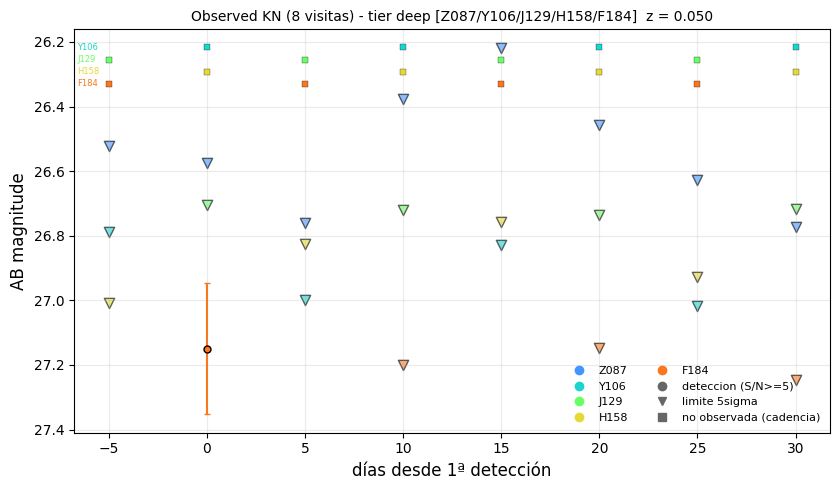

In [9]:
def plot_lightcurve_with_error(photometry, title='', ax=None):
    own_axis = ax is None
    if own_axis:
        figure, ax = plt.subplots(figsize=(8.5, 5))
    # Eje de tiempo unificado con el pipeline y el notebook OpenUniverse: días desde la 1ª detección.
    present_bands = [band for band in TIER_BANDS if (photometry['band'] == band).any()]
    # Magnitud mas debil realmente mostrada (deteccion o limite 5sigma) en TODO el objeto: los cuadrados de
    # gap van todos 1 mag por debajo de ella (misma altura), separados horizontalmente dentro de cada epoca
    # para no solaparse entre si ni con los datos.
    observed_rows = photometry[photometry['observed']]
    shown_magnitude = np.where(observed_rows['detected'], observed_rows['mag_observed'], observed_rows['mag_limit_5sigma'])
    shown_magnitude = shown_magnitude[np.isfinite(shown_magnitude)]
    square_magnitude = (shown_magnitude.max() + 1.0) if len(shown_magnitude) else 25.0
    gaps_by_epoch = {}
    for band in present_bands:
        band_rows = photometry[photometry['band'] == band].sort_values('days_since_detection')
        color = BAND_COLOR[band]
        band_observed = band_rows[band_rows['observed']]
        detections = band_observed[band_observed['detected']]
        upper_limits = band_observed[~band_observed['detected']]
        if len(detections) > 0:
            ax.errorbar(detections['days_since_detection'], detections['mag_observed'], yerr=detections['mag_err'],
                        fmt='o-', color=color, markersize=5, markeredgecolor='black', capsize=2)
        if len(upper_limits) > 0:
            ax.scatter(upper_limits['days_since_detection'], upper_limits['mag_limit_5sigma'], marker='v', s=55,
                       color=color, edgecolor='black', alpha=0.6)
        for epoch_time in band_rows.loc[~band_rows['observed'], 'days_since_detection']:
            gaps_by_epoch.setdefault(epoch_time, []).append(band)
    for epoch_time, gap_bands in gaps_by_epoch.items():
        count = len(gap_bands)
        for position, band in enumerate(gap_bands):
            offset = (position - (count - 1) / 2) * (BASE_CADENCE_DAYS * 0.14)
            ax.scatter(epoch_time + offset, square_magnitude, marker='s', s=22,
                       color=BAND_COLOR[band], edgecolor='black', linewidth=0.3, alpha=0.75, zorder=5)
    ax.invert_yaxis()
    ax.set_xlabel('días desde 1ª detección', fontsize=12)
    ax.set_ylabel('AB magnitude', fontsize=12)
    ax.set_title(title, fontsize=10)
    band_handles = [plt.Line2D([], [], marker='o', ls='', color=BAND_COLOR[band], label=band)
                    for band in present_bands]
    symbol_handles = [plt.Line2D([], [], marker='o', ls='', color='0.4', label='deteccion (S/N>=5)'),
                      plt.Line2D([], [], marker='v', ls='', color='0.4', label='limite 5sigma'),
                      plt.Line2D([], [], marker='s', ls='', color='0.4', label='no observada (cadencia)')]
    ax.legend(handles=band_handles + symbol_handles, frameon=False, fontsize=8, ncol=2, loc='best')
    ax.grid(alpha=0.25)
    if own_axis:
        plt.tight_layout()
        plt.show()


def cadence_observed_flag(lightcurve, bands=TIER_BANDS, anchor=ANCHOR_BAND):
    """Por (visita, banda): True si la cadencia HLTDS observa esa banda en esa visita (anchor + 2), via
    roman_photometry.bands_observed_at_visit indexado por la posicion temporal de la visita (dt creciente
    desde la 1ª visita, NO desde la deteccion)."""
    epoch_position_by_dt = {delta_time: position
                            for position, delta_time in enumerate(np.sort(lightcurve['dt'].unique()))}
    return np.array([band in bands_observed_at_visit(epoch_position_by_dt[delta_time], bands, anchor)
                     for delta_time, band in zip(lightcurve['dt'], lightcurve['band'])])


def estimate_observation_error(lightcurve, bands=TIER_BANDS, anchor=ANCHOR_BAND,
                               exposure_time=None, noise_floor_variance=None, plot=True):
    """Error fotometrico Roman por (epoca, banda) con la receta de roman_photometry: mag_true -> flux en
    electrones -> sigma_flux (Poisson de la fuente + piso de ruido NEA) -> SNR, mag_err, flag de deteccion.
    Conserva TODAS las (epoca, banda del tier): las que la cadencia NO observa (o sin mag_true) quedan como
    gap observed=False con fotometria NaN, igual que el camino OpenUniverse, para que la KN tambien lleve
    sus cuadrados. exposure_time/noise_floor_variance dependen del tier (default = globales del tier activo);
    days_since_detection cero en la 1ª deteccion S/N>=5."""
    exposure_time = EXPOSURE_TIME if exposure_time is None else exposure_time
    noise_floor_variance = NOISE_FLOOR_VARIANCE if noise_floor_variance is None else noise_floor_variance
    full = lightcurve[lightcurve['band'].isin(bands)].copy()
    on_cadence = cadence_observed_flag(full, bands=bands, anchor=anchor)
    full['observed'] = on_cadence & full['mag_true'].notna().to_numpy()
    for column in ['mag_observed', 'mag_err', 'snr', 'mag_limit_5sigma']:
        full[column] = np.nan
    full['detected'] = False

    observed_mask = full['observed'].to_numpy()
    observed = full[observed_mask]
    object_seed = int(full['object'].iloc[0])
    jitter_random = np.random.default_rng(object_seed)
    zeropoint_jitter = jitter_random.normal(0.0, ZP_JITTER_SIGMA, size=len(observed))
    zeropoint = observed['band'].map(ROMAN_ZEROPOINT).to_numpy() + zeropoint_jitter
    exposure = observed['band'].map(exposure_time).to_numpy()
    noise_floor = observed['band'].map(noise_floor_variance).to_numpy()

    flux_electrons = source_flux_electrons(observed['mag_true'].to_numpy(), exposure, zeropoint)
    flux_error = flux_error_electrons(flux_electrons, noise_floor)
    signal_to_noise = flux_electrons / flux_error
    full.loc[observed_mask, 'snr'] = signal_to_noise
    full.loc[observed_mask, 'mag_err'] = 1.0857 / signal_to_noise
    full.loc[observed_mask, 'detected'] = signal_to_noise >= SNR_DETECTION
    # Para no-detecciones: limite 5sigma (la fuente es mas debil que esto), consistente con el zeropoint
    # con jitter de esa epoca.
    full.loc[observed_mask, 'mag_limit_5sigma'] = limiting_magnitude_5sigma(flux_error, exposure, zeropoint)
    full.loc[observed_mask, 'mag_observed'] = observed['mag_true'].to_numpy()
    # Eje de tiempo unificado: días desde la 1ª detección S/N>=5 (cero en esa visita).
    detected_dt = full.loc[full['detected'], 'dt']
    reference_dt = detected_dt.min() if len(detected_dt) > 0 else full['dt'].min()
    full['days_since_detection'] = full['dt'] - reference_dt
    if plot:
        redshift = float(full['redshift'].iloc[0])
        plot_lightcurve_with_error(
            full, title=f'Observed KN ({N_VISITS} visitas) - tier {TIER} [{"/".join(bands)}]  z = {redshift:.3f}',
        )
    return full


observed_lightcurve = estimate_observation_error(clean_lightcurve, plot=True)

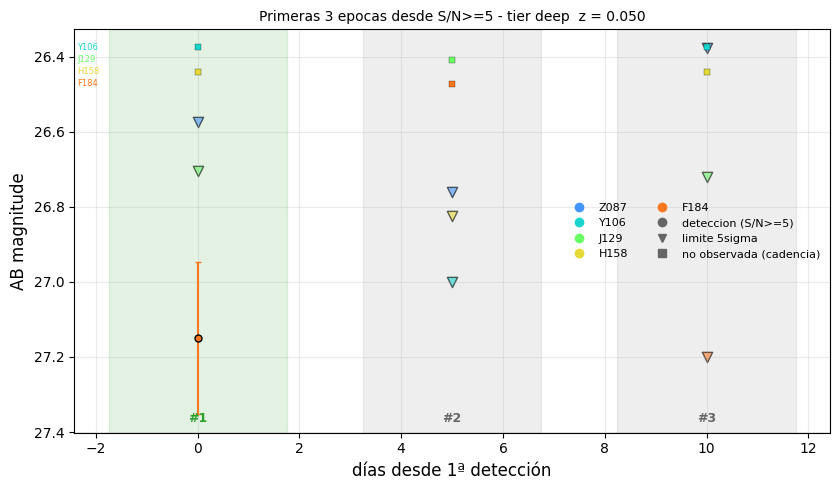

,days_since_detection,band,mag_true,mag_err,snr,detected
11,0.0,F184,27.150059,0.202841,5.352469,True
9,0.0,J129,27.370633,0.400780,2.708970,False
7,0.0,Z087,29.320917,2.721668,0.398910,False
16,5.0,H158,27.956800,0.616238,1.761819,False
14,5.0,Y106,30.084815,3.722934,0.291625,False
13,5.0,Z087,31.583714,18.440864,0.058875,False
23,10.0,F184,29.728962,2.232234,0.486374,False
21,10.0,J129,29.594151,3.063123,0.354442,False
19,10.0,Z087,32.777134,78.889431,0.013762,False


In [10]:
# Misma regla "primera detección -> N épocas" de roman_photometry (eje 'days_since_detection'); aquí solo el plot.
from roman_photometry import first_epochs_since_detection as select_first_epochs


def first_epochs_since_detection(photometry, number=N_EPOCHS_FROM_DETECTION, plot=True):
    """Las `number` ÉPOCAS (visitas, cada BASE_CADENCE_DAYS d) desde la PRIMERA deteccion S/N>=5 en
    cualquier banda (regla en roman_photometry.first_epochs_since_detection, eje 'days_since_detection').
    Por construccion la 1ª epoca cae en days_since_detection=0; de ahi se toman `number` visitas
    consecutivas. Una visita sin ninguna deteccion igual cuenta como epoca. Mismo criterio que el
    notebook OpenUniverse y el pipeline."""
    window = select_first_epochs(photometry, number=number, time_column="days_since_detection")
    if len(window) == 0:
        print('Sin deteccion S/N>=5: el objeto nunca supera el umbral (todo limites superiores).')
        if plot:
            plot_lightcurve_with_error(photometry, title='sin deteccion S/N>=5')
        return window
    epoch_times = np.sort(window['days_since_detection'].unique())
    if plot:
        figure, ax = plt.subplots(figsize=(8.5, 5))
        plot_lightcurve_with_error(
            window, title=f'Primeras {number} epocas desde S/N>=5 - tier {TIER}  z = {window["redshift"].iloc[0]:.3f}',
            ax=ax,
        )
        # Sombrear y numerar cada epoca seleccionada; verde = tiene deteccion, gris = sin deteccion.
        for order, epoch in enumerate(epoch_times, start=1):
            has_detection = bool(window[(window['days_since_detection'] == epoch) & window['detected']].shape[0])
            ax.axvspan(epoch - BASE_CADENCE_DAYS * 0.35, epoch + BASE_CADENCE_DAYS * 0.35,
                       color='tab:green' if has_detection else '0.5', alpha=0.13, zorder=0)
            ax.text(epoch, 0.02, f'#{order}', transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', fontsize=9, fontweight='bold',
                    color='tab:green' if has_detection else '0.4')
        plt.tight_layout()
        plt.show()
    return window


early_window = first_epochs_since_detection(observed_lightcurve, plot=True)
early_window[['days_since_detection', 'band', 'mag_true', 'mag_err', 'snr', 'detected']]


## Parte 3 — HDF5 de kilonovas en un rango de redshift

Genera `n_objects` kilonovas con redshift ~ U[`redshift_min`, `redshift_max`] y las escribe en un HDF5, **un grupo por objeto** (mismo estilo que el `snana_<healpix>.hdf5` de OpenUniverse que lee la Parte 1). Para cada kilonova: realización (simulación + ángulo + offset de explosión) sorteada del split → curva limpia (Parte 1) → error Roman (Parte 2) → ventana de las `N_EPOCHS_FROM_DETECTION` épocas desde la 1ª detección.

El sorteo es **uniforme en z** y **descarta** las kilonovas que no alcanzan S/N ≥ 5 (las débiles a alto z), re-sorteando hasta juntar `n_objects` detectadas. Cada grupo lleva en `attrs` el redshift y la realización, y como datasets la ventana temprana (`days_since_detection`, `band`, `mag_observed`, `mag_err`, `detected`, …).


In [ ]:
import os
from pathlib import Path
import h5py

# Override con OUTPUT_HDF5_DIR; por defecto el directorio del notebook (data/openuniverse).
OUTPUT_HDF5_TEMPLATE = str(
    Path(os.environ.get('OUTPUT_HDF5_DIR', Path.cwd())) / 'kilonova_windows_{tier}.hdf5'
)
WINDOW_DATASET_COLUMNS = ['mag_true', 'mag_observed', 'mag_err', 'snr', 'mag_limit_5sigma']
KN_TIERS = ['deep', 'wide']


def tier_photometry_constants(tier, field_seed=FIELD_SEED):
    """(bands, anchor, exposure_time, noise_floor_variance) del tier, derivados en roman_photometry a la
    exposicion del tier y el campo de field_seed. La misma curva KN limpia se observa en deep y wide con
    estas constantes (filtros, exposicion y piso de ruido distintos por tier)."""
    exposure_time = EXPOSURE_TIME_BY_TIER[tier]
    bands = [band for band in ALL_ROMAN_BANDS if band in exposure_time]
    anchor = TIER_ANCHOR_BAND[tier]
    noise_floor_variance = build_tier_constants(tier, field_seed=field_seed)['noise_floor_variance']
    return bands, anchor, exposure_time, noise_floor_variance


def plot_generated_sample(summary, redshift_min, redshift_max, tier):
    figure, (axis_z, axis_det) = plt.subplots(1, 2, figsize=(11, 4))
    axis_z.hist(summary['redshift'], bins=20, range=(redshift_min, redshift_max), color='C0', alpha=0.8)
    axis_z.set_xlabel('redshift'); axis_z.set_ylabel('kilonovas')
    axis_z.set_title(f'z de la muestra detectada (tier {tier})'); axis_z.grid(alpha=0.25)
    counts = summary['n_detected'].value_counts().sort_index()
    axis_det.bar(counts.index.astype(int), counts.values, color='C3', alpha=0.8)
    axis_det.set_xlabel('épocas con S/N>=5 en la ventana'); axis_det.set_ylabel('kilonovas')
    axis_det.set_title(f'detecciones por objeto (tier {tier})'); axis_det.grid(alpha=0.25, axis='y')
    plt.tight_layout(); plt.show()


def build_kilonova_window(redshift, realization_seed, noise_object_id, bands, anchor,
                          exposure_time, noise_floor_variance, split='train', number=N_EPOCHS_FROM_DETECTION):
    """Una KN al `redshift` dado: realizacion (sim/angulo/offset) sorteada con realization_seed -> curva
    limpia (tier-independiente) -> error Roman del tier (ruido sembrado con noise_object_id) -> ventana de
    `number` epocas desde la 1a deteccion. Devuelve (window, realization); window None si no se detecta."""
    clean_lightcurve, realization = build_clean_lightcurve(
        redshift, split=split, random_seed=realization_seed, plot=False,
    )
    clean_lightcurve = clean_lightcurve.copy()
    clean_lightcurve['object'] = noise_object_id
    observed = estimate_observation_error(
        clean_lightcurve, bands=bands, anchor=anchor,
        exposure_time=exposure_time, noise_floor_variance=noise_floor_variance, plot=False,
    )
    window = select_first_epochs(observed, number=number, time_column='days_since_detection')
    if len(window) == 0:
        return None, realization
    return window, realization


def generate_kilonova_hdf5(n_objects, redshift_min, redshift_max, tier, output_path=None,
                           split='train', number=N_EPOCHS_FROM_DETECTION, random_seed=0,
                           max_attempts_per_object=50, plot=True):
    """Genera n_objects kilonovas DETECTADAS en `tier` con z ~ U[redshift_min, redshift_max] y las escribe
    en un HDF5, un grupo por objeto. Sortea z uniforme y descarta las que no alcanzan S/N>=5, re-sorteando
    hasta juntar n_objects. Cada grupo: attrs (redshift, simulation_id, angle_index, explosion_offset_days,
    label, gentype, n_detected) + datasets de la ventana temprana (incluido observed para los gaps)."""
    output_path = OUTPUT_HDF5_TEMPLATE.format(tier=tier) if output_path is None else output_path
    bands, anchor, exposure_time, noise_floor_variance = tier_photometry_constants(tier)
    rng = np.random.default_rng(random_seed)
    records = []
    attempts = 0
    max_attempts = n_objects * max_attempts_per_object
    with h5py.File(output_path, 'w') as hdf5:
        hdf5.attrs['tier'] = tier
        hdf5.attrs['bands'] = ','.join(bands)
        hdf5.attrs['number_epochs'] = number
        hdf5.attrs['redshift_min'] = redshift_min
        hdf5.attrs['redshift_max'] = redshift_max
        while len(records) < n_objects and attempts < max_attempts:
            attempts += 1
            redshift = float(rng.uniform(redshift_min, redshift_max))
            realization_seed = int(rng.integers(0, 2 ** 32 - 1))
            noise_object_id = int(rng.integers(0, 2 ** 32 - 1))
            window, realization = build_kilonova_window(
                redshift, realization_seed, noise_object_id, bands, anchor,
                exposure_time, noise_floor_variance, split=split, number=number,
            )
            if window is None:
                continue
            object_index = len(records)
            group = hdf5.create_group(str(object_index))
            group.attrs['redshift'] = redshift
            group.attrs['simulation_id'] = realization['simulation_id']
            group.attrs['angle_index'] = realization['angle_index']
            group.attrs['explosion_offset_days'] = realization['explosion_offset_days']
            group.attrs['label'] = 'KN'
            group.attrs['gentype'] = 50
            group.attrs['n_detected'] = int(window['detected'].sum())
            group.create_dataset('days_since_detection', data=window['days_since_detection'].to_numpy(dtype=float))
            group.create_dataset('band', data=np.array(window['band'].tolist(), dtype='S8'))
            group.create_dataset('detected', data=window['detected'].to_numpy(dtype=bool))
            group.create_dataset('observed', data=window['observed'].to_numpy(dtype=bool))
            for column in WINDOW_DATASET_COLUMNS:
                group.create_dataset(column, data=window[column].to_numpy(dtype=float))
            records.append({'object_index': object_index, 'redshift': redshift,
                            'simulation_id': realization['simulation_id'],
                            'angle_index': realization['angle_index'],
                            'explosion_offset_days': realization['explosion_offset_days'],
                            'n_detected': int(window['detected'].sum()), 'n_rows': len(window)})
    summary = pd.DataFrame(records)
    efficiency = len(summary) / attempts if attempts else 0.0
    print(f'[{tier}] {len(summary)}/{n_objects} kilonovas escritas en {output_path}  '
          f'({attempts} sorteos, eficiencia {efficiency:.1%})')
    if len(summary) < n_objects:
        print(f'  AVISO: solo {len(summary)} detectadas en {max_attempts} intentos; baja el redshift '
              f'o sube max_attempts_per_object.')
    if plot and len(summary) > 0:
        plot_generated_sample(summary, redshift_min, redshift_max, tier)
    return summary

# La generacion (demo + corrida completa) se hace en paralelo en la celda siguiente.


## Parte 3b — Generación paralela del HDF5

Misma lógica que `generate_kilonova_hdf5` pero repartiendo los **intentos** entre procesos. Cada intento es independiente: su semilla sale de `np.random.SeedSequence(random_seed).spawn(...)` indexada por número de intento, así el resultado es **determinista respecto a `random_seed` e independiente del número de workers** (`n_workers`). Se conservan las primeras `n_objects` kilonovas **detectadas en orden de intento**; el HDF5 lo escribe un único proceso (el principal) al final.

Los workers usan el contexto `fork`, de modo que heredan `catalog`, `simulation_splits`, `simulation_time_grids` y `spectrum_id_lookup` sin necesidad de serializarlos. El cuello de botella real (los escaneos de row-group de `lanl_spectra.parquet` en `load_lanl_flux`) se paraleliza así sobre todos los cores.


In [ ]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor


def attempt_kilonova(task):
    """Un intento independiente: sortea (z, realizacion, ruido) desde attempt_seed y construye la ventana.
    Devuelve (redshift, realization, window) si la KN se detecta, o None. Corre en un worker que heredo
    catalog/simulation_splits/grids via fork."""
    (attempt_seed, redshift_min, redshift_max, bands, anchor,
     exposure_time, noise_floor_variance, split, number) = task
    random_generator = np.random.default_rng(attempt_seed)
    redshift = float(random_generator.uniform(redshift_min, redshift_max))
    realization_seed = int(random_generator.integers(0, 2 ** 32 - 1))
    noise_object_id = int(random_generator.integers(0, 2 ** 32 - 1))
    window, realization = build_kilonova_window(
        redshift, realization_seed, noise_object_id, bands, anchor,
        exposure_time, noise_floor_variance, split=split, number=number,
    )
    if window is None:
        return None
    return redshift, realization, window


def write_kilonova_hdf5(detected, output_path, tier, bands, number, redshift_min, redshift_max):
    """Escribe las KN detectadas (lista de (redshift, realization, window)) en un HDF5, un grupo por
    objeto. Mismo esquema que generate_kilonova_hdf5 / el snana_<healpix>.hdf5 de OpenUniverse."""
    records = []
    with h5py.File(output_path, 'w') as hdf5:
        hdf5.attrs['tier'] = tier
        hdf5.attrs['bands'] = ','.join(bands)
        hdf5.attrs['number_epochs'] = number
        hdf5.attrs['redshift_min'] = redshift_min
        hdf5.attrs['redshift_max'] = redshift_max
        for object_index, (redshift, realization, window) in enumerate(detected):
            group = hdf5.create_group(str(object_index))
            group.attrs['redshift'] = redshift
            group.attrs['simulation_id'] = realization['simulation_id']
            group.attrs['angle_index'] = realization['angle_index']
            group.attrs['explosion_offset_days'] = realization['explosion_offset_days']
            group.attrs['label'] = 'KN'
            group.attrs['gentype'] = 50
            group.attrs['n_detected'] = int(window['detected'].sum())
            group.create_dataset('days_since_detection', data=window['days_since_detection'].to_numpy(dtype=float))
            group.create_dataset('band', data=np.array(window['band'].tolist(), dtype='S8'))
            group.create_dataset('detected', data=window['detected'].to_numpy(dtype=bool))
            group.create_dataset('observed', data=window['observed'].to_numpy(dtype=bool))
            for column in WINDOW_DATASET_COLUMNS:
                group.create_dataset(column, data=window[column].to_numpy(dtype=float))
            records.append({'object_index': object_index, 'redshift': redshift,
                            'simulation_id': realization['simulation_id'],
                            'angle_index': realization['angle_index'],
                            'explosion_offset_days': realization['explosion_offset_days'],
                            'n_detected': int(window['detected'].sum()), 'n_rows': len(window)})
    return pd.DataFrame(records)


def generate_kilonova_hdf5_parallel(n_objects, redshift_min, redshift_max, tier, output_path=None,
                                    split='train', number=N_EPOCHS_FROM_DETECTION, random_seed=0,
                                    max_attempts_per_object=50, n_workers=None, plot=True):
    """Version paralela de generate_kilonova_hdf5: reparte los intentos entre n_workers procesos.
    Determinista respecto a random_seed e independiente de n_workers (cada intento tiene su SeedSequence
    fija por indice). Conserva las primeras n_objects KN detectadas en orden de intento."""
    output_path = OUTPUT_HDF5_TEMPLATE.format(tier=tier) if output_path is None else output_path
    bands, anchor, exposure_time, noise_floor_variance = tier_photometry_constants(tier)
    n_workers = n_workers or os.cpu_count()
    max_attempts = n_objects * max_attempts_per_object
    child_seeds = np.random.SeedSequence(random_seed).spawn(max_attempts)

    detected = []
    attempts_used = 0
    wave_size = max(n_workers * 4, n_objects)
    context = mp.get_context('fork')  # workers heredan catalog/splits/grids; no se serializan
    with ProcessPoolExecutor(max_workers=n_workers, mp_context=context) as executor:
        for wave_start in range(0, max_attempts, wave_size):
            if len(detected) >= n_objects:
                break
            tasks = [(seed, redshift_min, redshift_max, bands, anchor,
                      exposure_time, noise_floor_variance, split, number)
                     for seed in child_seeds[wave_start:wave_start + wave_size]]
            for result in executor.map(attempt_kilonova, tasks):
                attempts_used += 1
                if result is not None:
                    detected.append(result)
                    if len(detected) >= n_objects:
                        break

    detected = detected[:n_objects]
    summary = write_kilonova_hdf5(detected, output_path, tier, bands, number, redshift_min, redshift_max)
    efficiency = len(summary) / attempts_used if attempts_used else 0.0
    print(f'[{tier}] {len(summary)}/{n_objects} kilonovas escritas en {output_path}  '
          f'({attempts_used} intentos, eficiencia {efficiency:.1%}, {n_workers} workers)')
    if len(summary) < n_objects:
        print(f'  AVISO: solo {len(summary)} detectadas en {max_attempts} intentos; baja el redshift '
              f'o sube max_attempts_per_object.')
    if plot and len(summary) > 0:
        plot_generated_sample(summary, redshift_min, redshift_max, tier)
    return summary


# demo: 15 kilonovas detectadas por tier con z ~ U[0.01, 0.12], en deep y wide (en paralelo).
sample_summaries = {}
for tier_index, tier in enumerate(KN_TIERS):
    sample_summaries[tier] = generate_kilonova_hdf5_parallel(
        n_objects=15, redshift_min=0.01, redshift_max=0.12, tier=tier,
        random_seed=tier_index, n_workers=None, plot=True,
    )

# read-back: estructura de cada HDF5 (un grupo por objeto)
for tier in KN_TIERS:
    with h5py.File(OUTPUT_HDF5_TEMPLATE.format(tier=tier), 'r') as hdf5:
        print(f'\n[{tier}] archivo attrs:', {key: hdf5.attrs[key] for key in hdf5.attrs})
        print(f'[{tier}] grupos (objetos):', len(hdf5.keys()))
        example = hdf5['0']
        print(f'[{tier}] object 0 bands:', [b.decode() for b in example['band'][:]])
        print(f'[{tier}] object 0 observed:', example['observed'][:])
        print(f'[{tier}] object 0 detected:', example['detected'][:])
sample_summaries['deep']
